# Model Prediktif Mesin Forging (F2) — Hybrid DNN-SVM

Pipeline: sensor -> DNN (feature extractor) -> SVM (classifier), dengan SMOTE untuk menangani class imbalance, serta SHAP & LIME untuk explainability. Struktur mengikuti `compressor_model.ipynb` / `induksi_model.ipynb` yang sudah divalidasi.

Catatan: ADASYN tidak dipakai di sini dengan alasan yang sama seperti pada mesin Induksi — kelas minoritas (`Fault`) terpisah cukup jauh dari kelas mayoritas pada sensor getaran (`vx`, `vy`, `vz`), sehingga ADASYN berisiko gagal menghitung rasio kepadatan tetangga. SMOTE tidak memiliki batasan ini.


In [1]:
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [2]:
data = pd.read_csv("sensor-mesin-forging-f2-augmented.csv")

print(f"Shape: {data.shape}")
data.head()


Shape: (5000, 6)


,id,tekanan_bar,vx,vy,vz,status
0,1,6.825,0.6789,0.6479,0.6075,Ok
1,2,6.846,0.6893,0.6539,0.5956,Ok
2,3,6.817,0.6831,0.6369,0.5977,Ok
3,4,7.034,0.6868,0.6505,0.6225,Ok
4,5,6.901,0.6765,0.6547,0.6229,Ok


In [3]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           5000 non-null   int64  
 1   tekanan_bar  5000 non-null   float64
 2   vx           5000 non-null   float64
 3   vy           5000 non-null   float64
 4   vz           5000 non-null   float64
 5   status       5000 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 234.5 KB


In [4]:
data.describe()


,id,tekanan_bar,vx,vy,vz
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,6.952369,0.939575,0.897752,0.846627
std,1443.520003,0.782066,0.648050,0.622245,0.592297
min,1.000000,4.019000,0.560200,0.304500,0.316300
25%,1250.750000,6.889000,0.676900,0.647000,0.607400
50%,2500.500000,7.005000,0.684200,0.654900,0.614500
75%,3750.250000,7.027000,0.694000,0.665100,0.624600
max,5000.000000,9.815000,5.085000,5.837800,5.864200


In [5]:
label_columns = ["status"]
feature_columns = ["tekanan_bar", "vx", "vy", "vz"]

# Kolom "id" (identifier) tidak diikutkan sebagai fitur karena tidak informatif
# secara statistik (hanya nomor urut baris).

TARGETS = {
    "status": {
        "label_map": {"Ok": 0, "Fault": 1},
        "class_names": ["Ok", "Fault"],
    },
}

print("Feature columns:", feature_columns)
print(f"Total features: {len(feature_columns)}")
print("\nClass distribution per target:")
for target in label_columns:
    print(f"  {target}: {data[target].value_counts().to_dict()}")


Feature columns: ['tekanan_bar', 'vx', 'vy', 'vz']
Total features: 4

Class distribution per target:
  status: {'Ok': 4250, 'Fault': 750}



  MODEL: STATUS

Train : {0: 2720, 1: 480}
Val   : {0: 680, 1: 120}
Test  : {0: 850, 1: 150}
After SMOTE: {1: 2720, 0: 2720}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

...

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 2.4808e-05 - val_accuracy: 1.0000 - val_loss: 8.8725e-09


Epoch 150/150


 1/85 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 1.9525e-07

71/85 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.9997 - loss: 3.2337e-04

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - loss: 3.5508e-04 - val_accuracy: 1.0000 - val_loss: 6.7407e-08


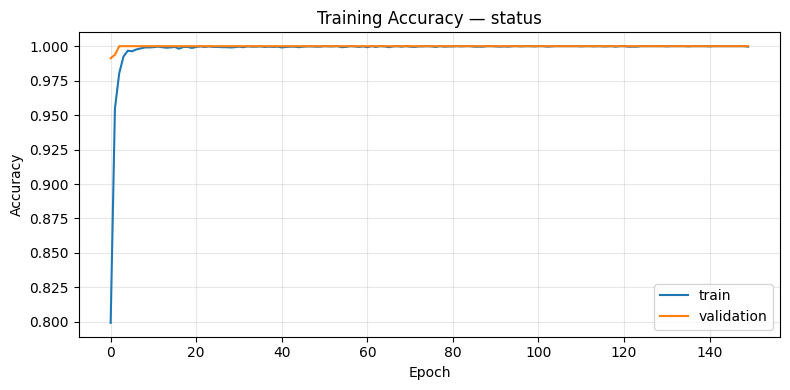


--- Metrics ---
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       1.00      1.00      1.00       850
       Fault       1.00      1.00      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



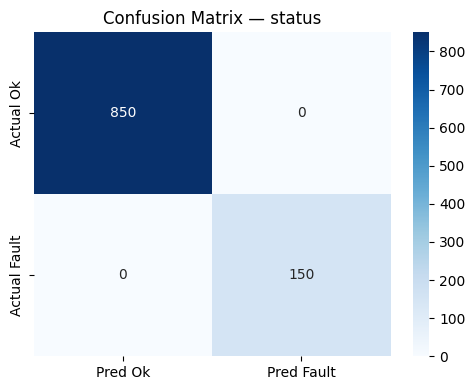

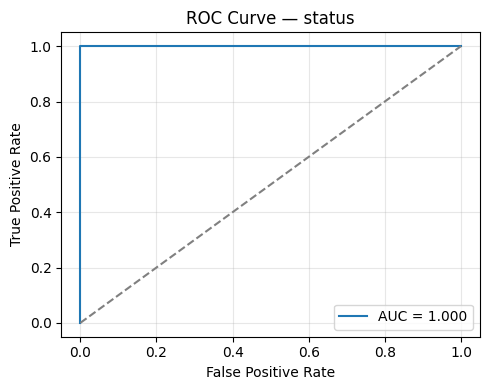

  0%|          | 0/50 [00:00<?, ?it/s]

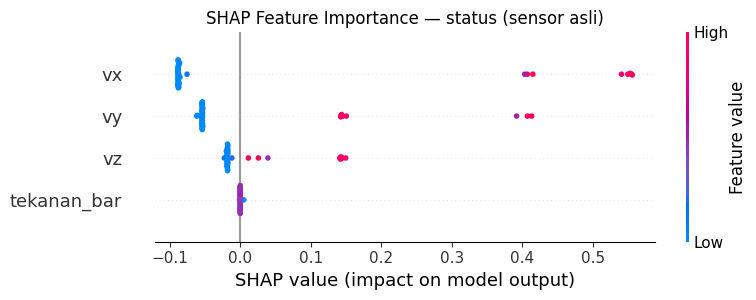

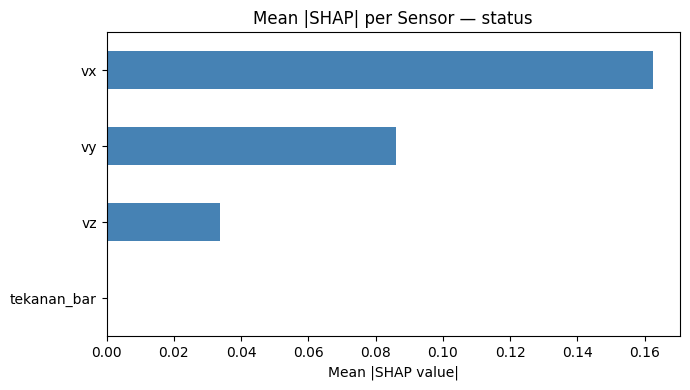

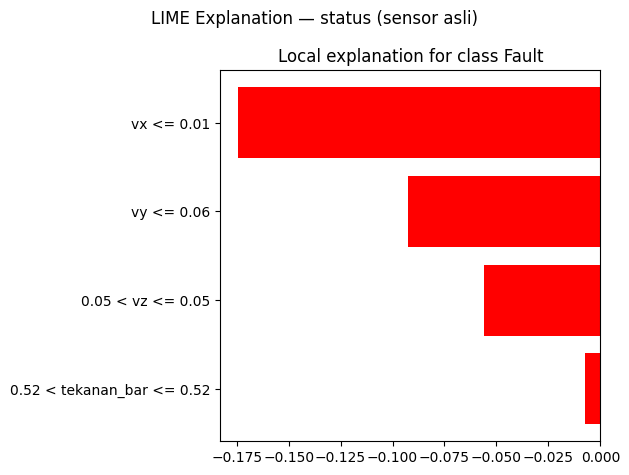

Saved: models/hybrid_model_status.pkl


In [6]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

all_metrics = {}

for target_column, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"  MODEL: {target_column.upper()}")
    print(f"{'='*60}\n")

    label_map = config["label_map"]
    class_names = config["class_names"]

    X = data[feature_columns].copy()
    y = data[target_column].map(label_map)

    # --- Split ---
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_train_raw, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    print(f"Train : {y_train.value_counts().to_dict()}")
    print(f"Val   : {y_val.value_counts().to_dict()}")
    print(f"Test  : {y_test.value_counts().to_dict()}")

    # --- Scale ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    # --- SMOTE ---
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

    # --- DNN ---
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name="latent_features"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_res, y_train_res,
        epochs=150,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    # Training history
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"Training Accuracy — {target_column}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature extractor ---
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("latent_features").output,
    )
    train_features_res = feature_extractor.predict(X_train_res, verbose=0)
    val_features       = feature_extractor.predict(X_val, verbose=0)
    test_features      = feature_extractor.predict(X_test, verbose=0)

    # --- SVM ---
    svm = SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", probability=True,
        random_state=RANDOM_STATE,
    )
    svm.fit(train_features_res, y_train_res)

    # --- Evaluation ---
    pred   = svm.predict(test_features)
    y_prob = svm.predict_proba(test_features)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_fault": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    all_metrics[target_column] = metrics

    print("\n--- Metrics ---")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    print(classification_report(y_test, pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Pred {c}" for c in class_names],
        yticklabels=[f"Actual {c}" for c in class_names],
    )
    plt.title(f"Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {target_column}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- SHAP (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    def pipeline_predict_proba(X_sensor):
        latent = feature_extractor.predict(X_sensor, verbose=0)
        return svm.predict_proba(latent)

    shap_background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
    shap_explainer = shap.KernelExplainer(
        pipeline_predict_proba,
        shap_background,
    )
    shap_values = shap_explainer.shap_values(X_test[:50])
    # shap_values shape: (n_samples, n_features, n_classes) -> ambil kelas fault (index 1)
    sv_arr = np.array(shap_values)
    if sv_arr.ndim == 3:
        sv_fault = sv_arr[:, :, 1]   # (n_samples, n_features) untuk kelas fault
    elif isinstance(shap_values, list):
        sv_fault = np.array(shap_values[1])
    else:
        sv_fault = sv_arr
    shap.summary_plot(sv_fault, X_test[:50], feature_names=feature_columns, show=False)
    plt.title(f"SHAP Feature Importance — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # Bar plot rata-rata |SHAP| per sensor
    mean_shap = np.abs(sv_fault).mean(axis=0)
    shap_df = pd.Series(mean_shap, index=feature_columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    shap_df.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Mean |SHAP| per Sensor — {target_column}")
    ax.set_xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # --- LIME (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    lime_explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_columns,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        X_test[0], pipeline_predict_proba, num_features=len(feature_columns)
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # --- Save ---
    model.save(models_dir / f"dnn_{target_column}.keras")
    feature_extractor.save(models_dir / f"dnn_extractor_{target_column}.keras")
    joblib.dump(
        {
            "scaler": scaler,
            "svm": svm,
            "feature_columns": feature_columns,
            "target_column": target_column,
            "label_mapping": label_map,
            "class_names": class_names,
            "metrics": metrics,
        },
        models_dir / f"hybrid_model_{target_column}.pkl",
    )
    print(f"Saved: models/hybrid_model_{target_column}.pkl")



  RINGKASAN METRICS — STATUS
  Accuracy        : 1.0000
  Balanced Acc    : 1.0000
  F1 Fault        : 1.0000
  ROC-AUC         : 1.0000


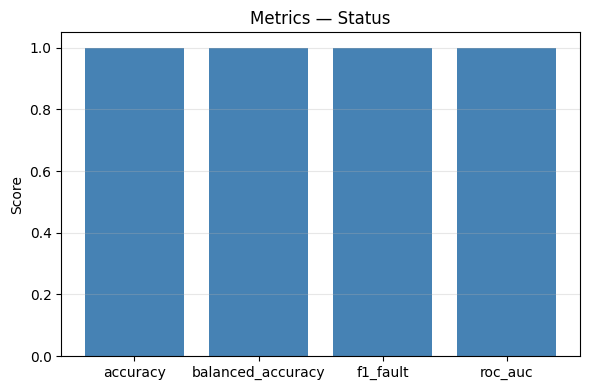

In [7]:
target_column = "status"
metrics = all_metrics[target_column]

print("\n" + "="*60)
print("  RINGKASAN METRICS — STATUS")
print("="*60)

print(f"  Accuracy        : {metrics['accuracy']:.4f}")
print(f"  Balanced Acc    : {metrics['balanced_accuracy']:.4f}")
print(f"  F1 Fault        : {metrics['f1_fault']:.4f}")
print(f"  ROC-AUC         : {metrics['roc_auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics.keys(), metrics.values(), color="steelblue")
ax.set_title("Metrics — Status")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


=== SVM Standalone (RBF) — tanpa DNN feature extractor ===
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

              precision    recall  f1-score   support

          Ok       1.00      1.00      1.00       850
       Fault       1.00      1.00      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



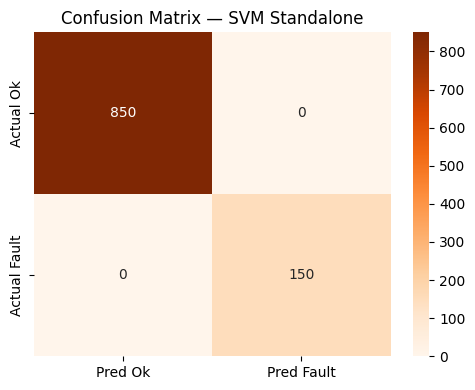

In [8]:
# ── Baseline 1: SVM Standalone (sensor langsung → SVM, tanpa DNN) ───────────
from sklearn.svm import SVC

svm_standalone = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE,
)
svm_standalone.fit(X_train_res, y_train_res)

pred_svm_sa = svm_standalone.predict(X_test)
prob_svm_sa = svm_standalone.predict_proba(X_test)[:, 1]

metrics_svm_standalone = {
    "accuracy":          accuracy_score(y_test, pred_svm_sa),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_svm_sa),
    "f1_fault":          f1_score(y_test, pred_svm_sa),
    "roc_auc":           roc_auc_score(y_test, prob_svm_sa),
}

print("=== SVM Standalone (RBF) — tanpa DNN feature extractor ===")
for k, v in metrics_svm_standalone.items():
    print(f"  {k}: {v:.4f}")
print()
print(classification_report(y_test, pred_svm_sa, target_names=["Ok", "Fault"]))

cm_svm = confusion_matrix(y_test, pred_svm_sa)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Pred Ok", "Pred Fault"],
            yticklabels=["Actual Ok", "Actual Fault"])
plt.title("Confusion Matrix — SVM Standalone")
plt.tight_layout()
plt.show()


=== Random Forest (n_estimators=100) ===
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

              precision    recall  f1-score   support

          Ok       1.00      1.00      1.00       850
       Fault       1.00      1.00      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



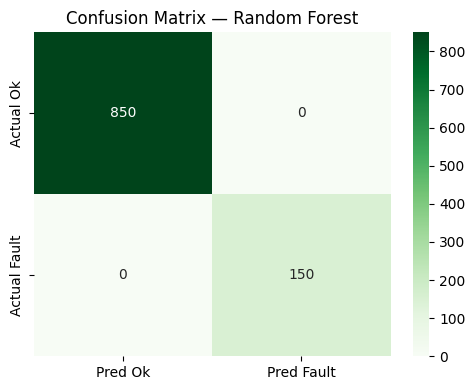

In [9]:
# ── Baseline 2: Random Forest ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
rf.fit(X_train_res, y_train_res)

pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    "accuracy":          accuracy_score(y_test, pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_rf),
    "f1_fault":          f1_score(y_test, pred_rf),
    "roc_auc":           roc_auc_score(y_test, prob_rf),
}

print("=== Random Forest (n_estimators=100) ===")
for k, v in metrics_rf.items():
    print(f"  {k}: {v:.4f}")
print()
print(classification_report(y_test, pred_rf, target_names=["Ok", "Fault"]))

cm_rf = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Ok", "Pred Fault"],
            yticklabels=["Actual Ok", "Actual Fault"])
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()



  TABEL PERBANDINGAN MODEL — Status (4 fitur, filtered data)
                    Model  Accuracy  Balanced Accuracy  F1 Fault  ROC-AUC
    Random Forest (n=100)    1.0000             1.0000    1.0000   1.0000
     SVM Standalone (RBF)    1.0000             1.0000    1.0000   1.0000
Hybrid DNN-SVM (Proposed)    1.0000             1.0000    1.0000   1.0000


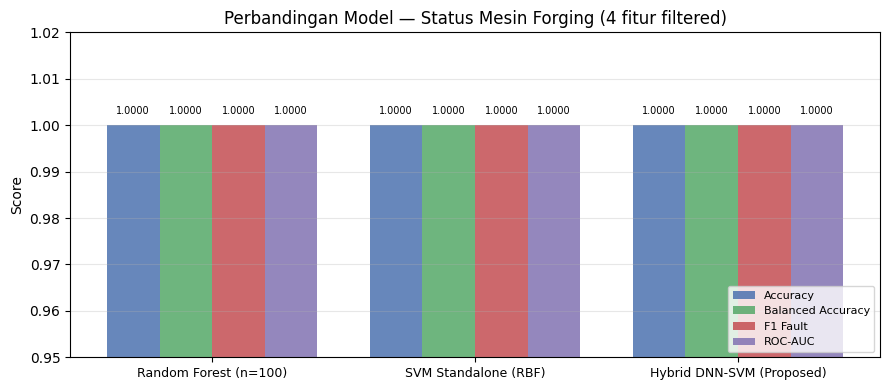

In [10]:
# ── Tabel Perbandingan Model ───────────────────────────────────────────────
hybrid_metrics = all_metrics["status"]

comparison = pd.DataFrame({
    "Model": [
        "Random Forest (n=100)",
        "SVM Standalone (RBF)",
        "Hybrid DNN-SVM (Proposed)",
    ],
    "Accuracy": [
        metrics_rf["accuracy"],
        metrics_svm_standalone["accuracy"],
        hybrid_metrics["accuracy"],
    ],
    "Balanced Accuracy": [
        metrics_rf["balanced_accuracy"],
        metrics_svm_standalone["balanced_accuracy"],
        hybrid_metrics["balanced_accuracy"],
    ],
    "F1 Fault": [
        metrics_rf["f1_fault"],
        metrics_svm_standalone["f1_fault"],
        hybrid_metrics["f1_fault"],
    ],
    "ROC-AUC": [
        metrics_rf["roc_auc"],
        metrics_svm_standalone["roc_auc"],
        hybrid_metrics["roc_auc"],
    ],
})

print("\n" + "="*65)
print("  TABEL PERBANDINGAN MODEL — Status (4 fitur, filtered data)")
print("="*65)
print(comparison.to_string(index=False, float_format="{:.4f}".format))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(comparison))
width = 0.2
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "F1 Fault", "ROC-AUC"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], comparison[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f"{h:.4f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(list(x))
ax.set_xticklabels(comparison["Model"], fontsize=9)
all_vals = comparison[metrics_to_plot].values.flatten()
ax.set_ylim(max(0.0, all_vals.min() - 0.05), min(1.02, all_vals.max() + 0.03))
ax.set_ylabel("Score")
ax.set_title("Perbandingan Model — Status Mesin Forging (4 fitur filtered)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



── Fold 1/5 ───────────────────────


  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

── Fold 2/5 ───────────────────────


  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

── Fold 3/5 ───────────────────────


  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

── Fold 4/5 ───────────────────────


  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

── Fold 5/5 ───────────────────────


  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000

  HASIL 5-FOLD CROSS-VALIDATION — Hybrid DNN-SVM (Status)
  Metric                     Mean       Std
  ------------------------------------------
  accuracy                 1.0000    0.0000
  balanced_accuracy        1.0000    0.0000
  f1_fault                 1.0000    0.0000
  roc_auc                  1.0000    0.0000

  Metric                  5-Fold Mean  Single Split
  --------------------------------------------------
  accuracy                     1.0000        1.0000
  balanced_accuracy            1.0000        1.0000
  f1_fault                     1.0000        1.0000
  roc_auc                      1.0000        1.0000


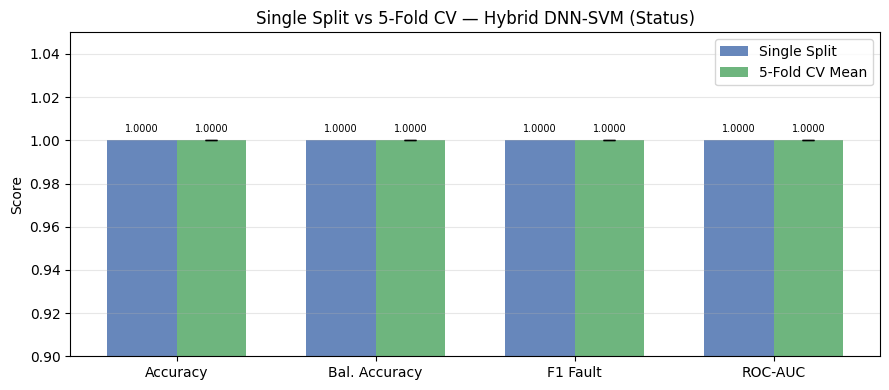

In [11]:
# ── 5-Fold Stratified Cross-Validation — Hybrid DNN-SVM ────────────────
# Melengkapi single train/test split agar hasil tidak terkesan kebetulan.
# Setiap fold: scale (fit hanya pada train fold) -> SMOTE -> DNN -> SVM
from sklearn.model_selection import StratifiedKFold

X_cv = data[feature_columns].values
y_cv = data["status"].map({"Ok": 0, "Fault": 1}).values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {"accuracy": [], "balanced_accuracy": [], "f1_fault": [], "roc_auc": []}

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\n── Fold {fold}/5 ───────────────────────")
    X_tr_raw_f, X_te_raw_f = X_cv[tr_idx], X_cv[te_idx]
    y_tr_f, y_te_f         = y_cv[tr_idx], y_cv[te_idx]

    sc_f = MinMaxScaler()
    X_tr_f = sc_f.fit_transform(X_tr_raw_f)
    X_te_f = sc_f.transform(X_te_raw_f)

    sm_f = SMOTE(random_state=RANDOM_STATE)
    X_tr_res_f, y_tr_res_f = sm_f.fit_resample(X_tr_f, y_tr_f)

    # Bagi sebagian train untuk val (EarlyStopping)
    X_tr2_f, X_val2_f, y_tr2_f, y_val2_f = train_test_split(
        X_tr_res_f, y_tr_res_f, test_size=0.1,
        stratify=y_tr_res_f, random_state=RANDOM_STATE
    )

    tf.random.set_seed(RANDOM_STATE)
    m_f = Sequential([
        Input(shape=(X_tr_res_f.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name=f"latent_f{fold}"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    m_f.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    es_f = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    m_f.fit(
        X_tr2_f, y_tr2_f, epochs=150, batch_size=64,
        validation_data=(X_val2_f, y_val2_f),
        callbacks=[es_f], shuffle=True, verbose=0,
    )

    fe_f = tf.keras.Model(inputs=m_f.inputs,
                          outputs=m_f.get_layer(f"latent_f{fold}").output)
    tr_feat_f = fe_f.predict(X_tr_res_f, verbose=0)
    te_feat_f = fe_f.predict(X_te_f, verbose=0)

    sv_f = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced",
               probability=True, random_state=RANDOM_STATE)
    sv_f.fit(tr_feat_f, y_tr_res_f)

    pred_f = sv_f.predict(te_feat_f)
    prob_f = sv_f.predict_proba(te_feat_f)[:, 1]

    fold_m = {
        "accuracy":          accuracy_score(y_te_f, pred_f),
        "balanced_accuracy": balanced_accuracy_score(y_te_f, pred_f),
        "f1_fault":          f1_score(y_te_f, pred_f),
        "roc_auc":           roc_auc_score(y_te_f, prob_f),
    }
    for k, v in fold_m.items():
        cv_results[k].append(v)
        print(f"  {k}: {v:.4f}")

# Ringkasan CV
print("\n" + "="*62)
print("  HASIL 5-FOLD CROSS-VALIDATION — Hybrid DNN-SVM (Status)")
print("="*62)
print(f"  {'Metric':<22} {'Mean':>8}  {'Std':>8}")
print(f"  {'-'*42}")
for k, vals in cv_results.items():
    print(f"  {k:<22} {np.mean(vals):>8.4f}  {np.std(vals):>8.4f}")

# Bandingkan 5-fold vs single split
single = all_metrics["status"]
print(f"\n  {'Metric':<22} {'5-Fold Mean':>12}  {'Single Split':>12}")
print(f"  {'-'*50}")
for k in cv_results:
    print(f"  {k:<22} {np.mean(cv_results[k]):>12.4f}  {single[k]:>12.4f}")

# Bar chart perbandingan
metrics_cv_mean  = [np.mean(cv_results[k]) for k in cv_results]
metrics_cv_std   = [np.std(cv_results[k])  for k in cv_results]
metrics_single   = [single[k] for k in cv_results]
labels_metric    = ["Accuracy", "Bal. Accuracy", "F1 Fault", "ROC-AUC"]

x = np.arange(len(labels_metric))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, metrics_single,   w, label="Single Split",   color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + w/2, metrics_cv_mean,  w, label="5-Fold CV Mean", color="#55A868", alpha=0.85,
               yerr=metrics_cv_std, capsize=4, error_kw={"elinewidth": 1.5})
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
            f"{h:.4f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels_metric)
all_cv_vals = metrics_single + metrics_cv_mean
ax.set_ylim(max(0.0, min(all_cv_vals) - 0.1), min(1.05, max(all_cv_vals) + 0.05))
ax.set_ylabel("Score")
ax.set_title("Single Split vs 5-Fold CV — Hybrid DNN-SVM (Status)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# ── Error Analysis — Sampel yang Salah Diklasifikasi ───────────────
# Variabel y_test, pred, y_prob, X_test_raw tersedia dari cell training loop (status)

err_df = X_test_raw.copy().reset_index(drop=True)
err_df["true_label"]  = y_test.values
err_df["pred_label"]  = pred
err_df["prob_fault"]  = y_prob
err_df["true_name"]   = err_df["true_label"].map({0: "Ok", 1: "Fault"})
err_df["pred_name"]   = err_df["pred_label"].map({0: "Ok", 1: "Fault"})
err_df["correct"]     = err_df["true_label"] == err_df["pred_label"]

misclassified  = err_df[~err_df["correct"]]
fp = misclassified[misclassified["true_label"] == 0]  # Ok diprediksi Fault
fn = misclassified[misclassified["true_label"] == 1]  # Fault diprediksi Ok

print(f"Total sampel test   : {len(err_df)}")
print(f"Benar diklasifikasi : {err_df['correct'].sum()} ({err_df['correct'].mean()*100:.1f}%)")
print(f"Salah diklasifikasi : {(~err_df['correct']).sum()} ({(~err_df['correct']).mean()*100:.1f}%)")
print(f"  False Positive (Ok diprediksi Fault) : {len(fp)}")
print(f"  False Negative (Fault diprediksi Ok) : {len(fn)}")

if len(misclassified) == 0:
    print("\nModel sempurna pada test set ini — tidak ada sampel yang salah.")
else:
    print("\n── Detail Sampel Salah Diklasifikasi ──")
    display_cols = feature_columns + ["true_name", "pred_name", "prob_fault"]
    print(misclassified[display_cols].round(4).to_string(index=False))

    # Rata-rata sensor per kelompok
    print("\n── Rata-rata Nilai Sensor per Kelompok ──")
    benar_ok    = err_df[(err_df["true_label"]==0) &  err_df["correct"]]
    benar_fault = err_df[(err_df["true_label"]==1) &  err_df["correct"]]
    groups = {"Benar - Ok": benar_ok, "Benar - Fault": benar_fault}
    if len(fp) > 0: groups["FP (Ok -> Fault)"] = fp
    if len(fn) > 0: groups["FN (Fault -> Ok)"] = fn

    summary = pd.DataFrame(
        {label: grp[feature_columns].mean() for label, grp in groups.items()}
    ).T
    print(summary.round(4).to_string())

    # Boxplot: posisi sampel salah pada distribusi sensor
    n_feat = len(feature_columns)
    fig, axes = plt.subplots(1, n_feat, figsize=(4*n_feat, 4), sharey=False)
    if n_feat == 1:
        axes = [axes]
    for ax, feat in zip(axes, feature_columns):
        ok_vals    = benar_ok[feat].values
        fault_vals = benar_fault[feat].values
        bp = ax.boxplot(
            [ok_vals, fault_vals], labels=["Ok", "Fault"],
            patch_artist=True, widths=0.5,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="navy", linewidth=2),
        )
        if len(fp) > 0:
            ax.scatter([1]*len(fp), fp[feat].values, color="orange",
                       zorder=6, marker="^", s=70, label="FP")
        if len(fn) > 0:
            ax.scatter([2]*len(fn), fn[feat].values, color="red",
                       zorder=6, marker="v", s=70, label="FN")
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=8)
    handles = []
    if len(fp) > 0:
        handles.append(plt.Line2D([0],[0], marker="^", color="orange", ls="", ms=8, label=f"FP ({len(fp)})"))
    if len(fn) > 0:
        handles.append(plt.Line2D([0],[0], marker="v", color="red",    ls="", ms=8, label=f"FN ({len(fn)})"))
    if handles:
        axes[-1].legend(handles=handles, fontsize=8, loc="best")
    plt.suptitle("Error Analysis: Posisi Sampel Salah pada Distribusi Sensor",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Confusion matrix detail
    cm_err = confusion_matrix(err_df["true_label"], err_df["pred_label"])
    print("\n── Confusion Matrix ──")
    print(f"  TN={cm_err[0,0]}  FP={cm_err[0,1]}")
    print(f"  FN={cm_err[1,0]}  TP={cm_err[1,1]}")
    print(f"  Precision fault: {cm_err[1,1]/(cm_err[0,1]+cm_err[1,1]+1e-9):.4f}")
    print(f"  Recall fault   : {cm_err[1,1]/(cm_err[1,0]+cm_err[1,1]+1e-9):.4f}")


Total sampel test   : 1000
Benar diklasifikasi : 1000 (100.0%)
Salah diklasifikasi : 0 (0.0%)
  False Positive (Ok diprediksi Fault) : 0
  False Negative (Fault diprediksi Ok) : 0

Model sempurna pada test set ini — tidak ada sampel yang salah.


In [13]:
# Kesimpulan Pipeline
#
# Dataset  : sensor-mesin-forging-f2-augmented.csv — 5000 baris, 4 sensor, 1 label (status)
# Sensor   : tekanan_bar, vx, vy, vz
#            (id dikecualikan: hanya nomor urut baris, bukan sensor)
# Target   : status (Ok / Fault)
# Metode   : DNN (feature extractor 16-dim) + SVM RBF (classifier)
#
# Pipeline:
# 1. Sensor dipilih: seluruh sensor numerik yang informatif pada mesin forging.
# 2. Split stratified: 64% train / 16% validation / 20% test.
# 3. MinMaxScaler hanya fit pada data train (mencegah data leakage).
# 4. SMOTE hanya pada train set untuk menangani class imbalance (4250 Ok : 750 Fault).
# 5. DNN mengekstrak 16 fitur laten dari 4 sensor.
# 6. SVM RBF mengklasifikasikan fitur laten.
# 7. Evaluasi: accuracy, balanced accuracy, F1 fault, ROC-AUC.
# 8. SHAP (global) + LIME (lokal) untuk explainability.
# 9. Model disimpan di folder models/.
